In [35]:
# ==============================================
# 1. Imports
# ==============================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import optuna   # find best parameter
import mlflow   # track experiments
import mlflow.xgboost

In [36]:
train_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/feature_engineered_train2.csv")
test_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/feature_engineered_test2.csv")
rul_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/rul_clean2.csv")

In [37]:
# Features & target
X = train_df.drop(columns=["engine_id", "rul"])
y = train_df["rul"]

test_last = test_df.groupby("engine_id").last().reset_index()
X_test = test_last.drop(columns=["engine_id"])
y_test = rul_df["rul"]

In [38]:
# Train / Evaluation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# Setup MLFlow
# Force MLflow to always use the root project mlruns folder
mlflow.set_tracking_uri("/Users/apple/Documents/Projects/Nasa RUL MLE/mlruns")
mlflow.set_experiment("NASA_Turbofan_RUL")

# Define optuna objective function with mlflow
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
    }

    with mlflow.start_run(nested=True):
        model = XGBRegressor(**params)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mae = float(mean_absolute_error(y_val, y_pred))
        r2 = float(r2_score(y_val, y_pred))

        # Log hyperparameters + metrics
        mlflow.log_params(params)
        mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})

    return rmse

In [40]:
# Run optuna
study = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="xgboost_optuna"):
    study.optimize(objective, n_trials=30)

    # Log best result
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_rmse", study.best_value)

[I 2026-06-04 15:08:07,106] A new study created in memory with name: no-name-a08490a3-ea28-4194-8ffe-3d1bc58d97c6
[I 2026-06-04 15:08:08,309] Trial 0 finished with value: 12.178605032204898 and parameters: {'n_estimators': 488, 'max_depth': 6, 'learning_rate': 0.15239244159068702, 'subsample': 0.7825199180684278, 'colsample_bytree': 0.8728256364516866, 'min_child_weight': 1, 'gamma': 1.9378370569600616, 'reg_alpha': 0.1753321373800773, 'reg_lambda': 0.0007064010637836179}. Best is trial 0 with value: 12.178605032204898.
[I 2026-06-04 15:08:14,664] Trial 1 finished with value: 10.855855369928138 and parameters: {'n_estimators': 947, 'max_depth': 9, 'learning_rate': 0.01078084179840747, 'subsample': 0.9359474163021506, 'colsample_bytree': 0.9199846254326708, 'min_child_weight': 1, 'gamma': 1.5914610735218289, 'reg_alpha': 1.227313282084114e-06, 'reg_lambda': 0.00011647154124944533}. Best is trial 1 with value: 10.855855369928138.
[I 2026-06-04 15:08:15,808] Trial 2 finished with value: 1

In [41]:
print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)

Best params: {'n_estimators': 758, 'max_depth': 10, 'learning_rate': 0.015415185889048591, 'subsample': 0.8337933364723915, 'colsample_bytree': 0.9484072551335024, 'min_child_weight': 3, 'gamma': 2.385442925318273, 'reg_alpha': 2.736366355851422e-07, 'reg_lambda': 8.413088435048862e-06}
Best RMSE: 10.595981778750152


In [42]:
# ==============================================
# Train final model with best params and log to MLflow
# ==============================================
best_params = study.best_trial.params
best_model = XGBRegressor(**best_params)
best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred_test = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print("Final tuned model performance:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

# Log final model
with mlflow.start_run(run_name="best_xgboost_model"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    mlflow.xgboost.log_model(best_model, name="model")

Final tuned model performance:
RMSE: 21.39942224025679
MAE: 15.495532989501953
R²: 0.7327638268470764


In [47]:
test_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/feature_engineered_test2.csv")
rul_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/rul_clean2.csv")

test_last = test_df.groupby("engine_id").last().reset_index()
X_test = test_last.drop(columns=["engine_id"])
y_test = rul_df["rul"]

In [48]:
X_test

,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,...,sensor_4_diff,sensor_7_diff,sensor_8_diff,sensor_9_diff,sensor_10_diff,sensor_11_diff,sensor_12_diff,sensor_13_diff,sensor_14_diff,sensor_17_diff
0,233,0.252652,0.634456,0.552420,1.566996,0.937856,1.070536,2.516144,0.380891,1.535713,...,-0.438892,0.504959,-0.129081,0.590386,-0.020213,0.042854,-1.712585,0.428608,-1.520960,-0.764802
1,124,0.195292,-0.096791,0.534002,-0.527688,0.685142,-0.657702,-0.353479,0.980755,-0.660740,...,-1.111866,1.057050,0.430449,1.056539,-0.020213,-0.228530,-0.057811,-0.239956,0.265541,-1.515066
2,234,0.558567,0.565443,1.349515,2.463055,1.506462,1.380347,2.516144,0.880778,2.552533,...,0.613930,0.228913,-0.017175,-0.801318,-0.020213,-0.499914,-0.552342,0.205753,0.747025,-0.014538
3,68,-0.340059,-0.499124,0.213731,-0.696426,-0.009822,-0.794840,-0.353479,-0.518905,-0.547077,...,0.291319,-1.841431,-0.240987,0.186724,-0.020213,-1.788987,-0.780586,0.205753,0.320008,-0.764802
4,138,-0.588616,-1.099687,-0.737872,-0.385133,-0.704785,-0.661706,-0.353479,-1.085443,-0.402695,...,-0.086795,0.290256,-0.240987,-0.966836,-0.020213,-0.228530,0.075331,0.651462,-1.337953,-0.014538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,358,0.826243,0.712280,0.492049,1.549540,0.874677,0.452915,2.516144,0.614172,1.434338,...,-0.242897,1.241081,0.094731,-1.427922,6.073413,1.331927,0.018270,-0.239956,-0.250801,-0.764802
96,95,-0.263580,-0.435984,-1.479714,-0.158209,-0.199357,-0.567111,-0.353479,-1.218746,-0.098571,...,-2.799504,0.658317,0.206637,-1.176267,-0.020213,-1.042681,2.110513,-0.685666,-0.032935,-0.014538
97,182,1.705749,0.602152,2.298049,-0.815707,0.811499,2.623598,-0.353479,1.380664,-0.669956,...,1.023265,0.673653,0.654261,0.722124,-0.020213,-0.771298,0.722025,-0.574238,2.285159,-0.014538
98,289,0.615926,1.393603,1.534720,3.324202,2.390961,2.083555,2.516144,2.247134,3.372747,...,-1.016470,-0.507209,-0.576705,-1.600196,-0.020213,-0.092838,-0.799607,0.094326,-0.488275,2.236255


In [64]:
import joblib
xgb_path = "/Users/apple/Documents/Projects/Nasa RUL MLE/models/best_xgb.pkl"
xgb_model = joblib.load(xgb_path)

In [66]:
preds_test = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
mae_test = mean_absolute_error(y_test, preds_test)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)

Test RMSE: 21.39942224025679
Test MAE: 15.495532989501953


In [67]:
result = pd.DataFrame({
    "engine_id": np.arange(1, len(y_test)+1),
    "true_rul": y_test,
    "pred_rul": preds_test,
    "residual": abs(y_test-preds_test)
})

In [68]:
result

,engine_id,true_rul,pred_rul,residual
0,1,44,48.352211,4.352211
1,2,51,80.272171,29.272171
2,3,27,23.350733,3.649267
3,4,120,116.327477,3.672523
4,5,101,121.123436,20.123436
...,...,...,...,...
95,96,113,84.015213,28.984787
96,97,123,117.939751,5.060249
97,98,17,13.271443,3.728557
98,99,8,10.712804,2.712804


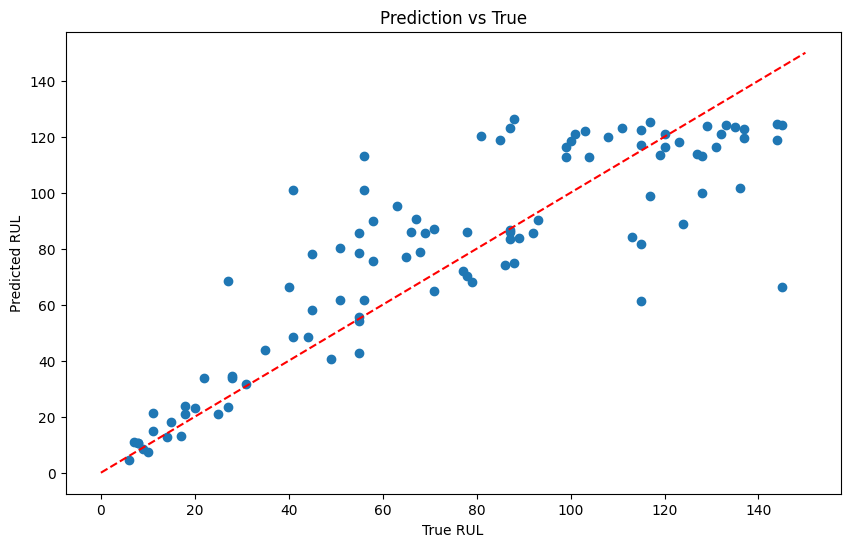

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, preds_test)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Prediction vs True")
plt.plot([0,150], [0,150], 'r--')
plt.show()